![Roboflow Banner](https://media.roboflow.com/quickstart/rf_linkedin_purple_tagline.png?ik-sdk-version=javascript-1.4.3&updatedAt=1676456797695)

# Roboflow Quickstart - Python

Roboflow is a set of tools to help you build a production ready computer vision workflow, fast. Roboflow empowers developers to deploy computer vision models with ease, providing utilities to help at every step of the way: from annotation to using your model in production.

In this notebook, we're going to load and test three separate example models:

1. Microsoft COCO
2. An American Sign Language detector
3. A construction safety equipment detector

You can use these models live in the notebook!

Roboflow is used by over 100,000 developers, and operates the world's largest [open-source reposistory of datasets](https://universe.roboflow.com). Companies from Walmart to Cardinal Health choose Roboflow to help them solve critical business needs with computer vision.

Roboflow publishes guides to help solve common computer vision problems, from [counting objects in zones](https://www.youtube.com/watch?v=l_kf9CfZ_8M&t=748s) to [tracking objects with state-of-the-art models](https://www.youtube.com/watch?v=OS5qI9YBkfk&t=154s). Check out our [blog](https://blog.roboflow.com/tag/tutorials/) and [YouTube channel](https://www.youtube.com/@Roboflow/videos) for more learning resources as your needs grow.

Let's start using computer vision models!

In [ ]:
#log into Roboflow
import roboflow
roboflow.login()

### Run Your Webcam on COCO (Common Objects in Context) Model

COCO model contains 80 classes of "common objects in context"

This is a list of the objects that COCO detects from the COCO explorer - https://cocodataset.org/#explore

![image info](https://i.imgur.com/mNW1tcR.png[/img)

In [2]:
# Show the COCO model your cell phone or a book to see how it does at detecting them

universe_model_url = "https://universe.roboflow.com/jacob-solawetz/microsoft-coco/dataset/9"

model = roboflow.load_model(model_url=universe_model_url)

# Running this cell will load the model onto your computer
# and use it to get predictions on images from your webcam

# inference_engine_url : The setup.sh script started an infrence server on your local machine at http://localhost:9001
# There will be more on the inference engine in future notebooks

model.webcam(inference_engine_url="http://localhost:9001/", webcam_id=0, within_jupyter=True, web_cam_res=(416,416), confidence=10)

loading Roboflow workspace...
loading Roboflow project...


'loading Roboflow model...'

ToggleButton(value=False, button_style='danger', description='Stop Inference', icon='square', tooltip='Descrip…

Exception in thread Thread-5 (view):
Traceback (most recent call last):
  File "/home/renzo/.pyenv/versions/3.12.5/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/home/renzo/PycharmProjects/quickstart-python/roboflow/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/home/renzo/.pyenv/versions/3.12.5/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/home/renzo/PycharmProjects/quickstart-python/roboflow/lib/python3.12/site-packages/roboflow/models/object_detection.py", line 408, in view
    raise Exception(str(json))
Exception: {'error': "Cannot read properties of undefined (reading 'backend')"}




## Warning for WSL Users

To run this example on WSL 2, you must expose your webcam from Windows to WSL.
We will use a utility called **usbipd** to accomplish this.

---

### 1. Install `usbipd-win`

Open **PowerShell** in Windows and run:

```powershell
winget install dorssel.usbipd-win
```

After installation, close the current PowerShell session.

---

### 2. Open PowerShell with Administrator Privileges

1. Search for "PowerShell" in the Start menu.
2. Right-click it and select **Run as administrator**.

---

### 3. List Available USB Devices

In the administrator PowerShell session, run:

```powershell
usbipd list
```

You will see output similar to:

```powershell
Connected:
BUSID  VID:PID    DEVICE                                                        STATE
1-8    046d:0ab7  Yeti Stereo Microphone, USB Input Device                      Not shared
1-17   046d:085e  Logitech BRIO                                                 Not shared
```

Identify your USB camera in the list.
In this example, the **Logitech BRIO** webcam is on **BUSID 1-17**.
Make note of your device’s `BUSID` — you will need it in the next steps.
(Replace `1-17` in the commands below with your actual `BUSID`.)

---

### 4. Bind and Attach the Webcam to WSL

Bind the device:

```powershell
usbipd bind --busid 1-17
```

Attach the device to WSL:

```powershell
usbipd attach --wsl --busid 1-17
```

---

### 5. Verify Camera Access in WSL

Inside your WSL terminal, check whether the camera is detected:

```bash
ls /dev/video*
```

If the command lists `/dev/video0` (or similar), your webcam is now available for use inside WSL.




### Run Your Webcam on American Sign Language Letters

We have a built a model to recognize American Sign Language (ASL) letters. Try it out below. See if you can get this model to detect a W hand sign

![image info](https://media.roboflow.com/quickstart/asl_diagram.jpeg?updatedAt=1678743042848[/img)


loading Roboflow project...


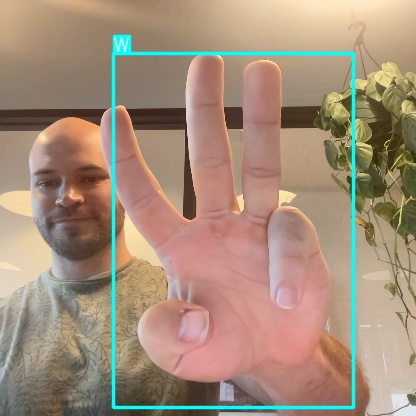

ToggleButton(value=False, button_style='danger', description='Stop Inference', icon='square', tooltip='Descrip…

In [6]:
#See if you can get this model to detect a W hand sign

from urllib.parse import urlparse
universe_model_url = "https://universe.roboflow.com/david-lee-d0rhs/american-sign-language-letters/model/6"

model = roboflow.load_model(model_url=universe_model_url)

model.webcam(inference_engine_url="http://localhost:9001/", webcam_id=0, within_jupyter=True, confidence=60)

## Roboflow Universe

[Roboflow Universe](universe.roboflow.com) is a repository of over 100,000 open source computer datasets and 11,000 community-shared models that you can leverage in your application for tasks from detecting license plates to counting pills. [Find a model](https://universe.roboflow.com/roboflow-universe-projects) and try it out:


loading Roboflow project...


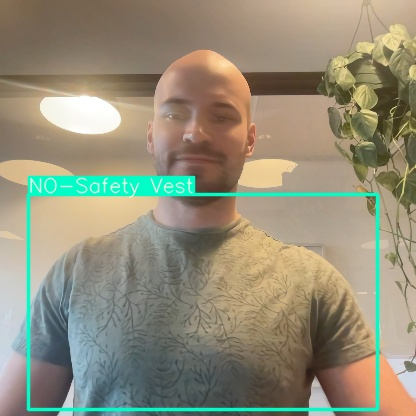

ToggleButton(value=False, button_style='danger', description='Stop Inference', icon='square', tooltip='Descrip…

In [7]:
#pick a model yourself
#https://universe.roboflow.com/roboflow-universe-projects
from urllib.parse import urlparse
universe_model_url = "https://universe.roboflow.com/roboflow-universe-projects/safety-vests/model/5"

model = roboflow.load_model(model_url=universe_model_url)

model.webcam(inference_engine_url="http://localhost:9001/", webcam_id=0, within_jupyter=True)

_**Note:** since all of the models on Roboflow Universe were shared by Roboflow users just like you, the models are of differing quality. If your model didn't work very well, try another one. Or create your own!_

## Next Up: Training Models

In the next part of the quickstart, we will re-train our own model to make better detections.

In [1]:
#onto the next notebook!
from notebook import notebookapp
import webbrowser
jupyter_server = list(notebookapp.list_running_servers())[0]["url"]
webbrowser.open(jupyter_server + "notebooks/create-models.ipynb")

True

In [1]:
#log into Roboflow
import roboflow
roboflow.login()

You are already logged into Roboflow. To make a different login,run roboflow.login(force=True).
